# Demo 3a: Comparing Literary Worlds

**Goal:** Vectorize the four-book corpus, inspect TF-IDF distinctive terms, compute pairwise similarity and visualize; build NLTK and spaCy pipeline functions.
**Texts:** Alice, Holmes, Pride and Prejudice, Frankenstein (excerpts in `data/`).
**Lecture:** Bag of Words, TF-IDF, N-grams, Document Similarity, Pipelines.

## Why This Matters for Health Data

Comparing documents—finding what's distinctive, measuring similarity, grouping related texts—is fundamental to clinical NLP workflows:

| Literary Analysis | Clinical Application |
| ----------------- | -------------------- |
| "What words distinguish Alice from Holmes?" | "What terms distinguish cardiology notes from neurology notes?" |
| "Which novels are most similar?" | "Which patients have similar presentations?" |
| "Find bigrams like 'my dear Watson'" | "Find phrases like 'chest pain', 'no fever', 'history of'" |
| "Build a reusable text pipeline" | "Build a clinical NLP pipeline for note processing" |

The techniques are identical. TF-IDF finds distinctive vocabulary. Cosine similarity measures document relatedness. N-grams capture multi-word clinical phrases. And the pipeline patterns—whether NLTK's explicit steps or spaCy's integrated approach—are what you'll use to process clinical corpora at scale.

We'll also cover **specialized spaCy models** for biomedical and clinical text at the end.

## Setup: all imports and paths

Run this cell first. We load NLTK (with data), spaCy, scikit-learn vectorizers and similarity, NumPy, and matplotlib. Paths, the corpus file list, and the spaCy model come from `config.yaml` so you can add or swap texts without editing code.

In [ ]:
import re
import string
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import numpy as np
import spacy
import yaml
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("maxent_ne_chunker_tab", quiet=True)
nltk.download("words", quiet=True)

DEMO_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
CONFIG_PATH = DEMO_DIR / "config.yaml"
with open(CONFIG_PATH) as f:
    CONFIG = yaml.safe_load(f)

DATA_DIR = DEMO_DIR / CONFIG["data"]["dir"]
nlp = spacy.load(CONFIG["spacy"]["model"])

## Load corpus

We read all excerpts listed in `config.yaml` (`data.files`) into a list of strings and keep their labels. The result is a small corpus we can feed into vectorizers. To add a fifth text, add an entry to `data.files` and re-run.

In [ ]:
labels = []
docs = []
for name, fname in CONFIG["data"]["files"].items():
    path = DATA_DIR / fname
    text = path.read_text(encoding="utf-8")
    labels.append(name)
    docs.append(text)

print("Corpus:", labels)
print("Word counts:", [len(d.split()) for d in docs])

Corpus: ['alice', 'holmes', 'pride', 'frankenstein']
Word counts: [2181, 3434, 1694, 2355]


## Bag of Words

**Why it matters:** Bag of words turns each document into a vector of word counts. The document–term matrix has one row per document and one column per vocabulary word, so we can compare documents by their counts.

We fit a `CountVectorizer` on the corpus and inspect vocabulary size and matrix shape.

In [ ]:
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(docs)
vocab = vectorizer.get_feature_names_out()
print("Vocabulary size:", len(vocab))
print("Sample terms:", list(vocab[:20]))
print("Document-term matrix (shape):", X_bow.toarray().shape)

Vocabulary size: 2172
Sample terms: ['1858', '1888', '1894', '_am_', '_are_', '_carte', '_copyright', '_curtseying_', '_have_', '_he_', '_her_', '_incognito_', '_may_', '_never_', '_not_', '_one_', '_poison_', '_that_', '_the_', '_there_']
Document-term matrix (shape): (4, 2172)


## TF-IDF and distinctive terms

**Why it matters:** TF-IDF downweights words that appear in many documents and upweights words that are distinctive to a document. The top TF-IDF terms per document summarize what makes that text different from the others.

We fit `TfidfVectorizer` with English stopwords so the top terms are content words, not "the"/"and".

In [ ]:
tfidf = TfidfVectorizer(stop_words="english")
X = tfidf.fit_transform(docs)
terms = tfidf.get_feature_names_out()

def top_tfidf(row_idx, n=10):
    row = X[row_idx].toarray().ravel()
    idx = np.argsort(row)[::-1][:n]
    return [(terms[i], row[i]) for i in idx if row[i] > 0]

for i, name in enumerate(labels):
    print(f"\n{name}: {top_tfidf(i)}")


alice: [('alice', 0.5774671425244805), ('ll', 0.18561443866858301), ('rabbit', 0.16499061214985158), ('little', 0.16143552365794542), ('went', 0.14436678563112013), ('way', 0.13991078717021935), ('wonder', 0.12374295911238868), ('going', 0.12374295911238868), ('key', 0.12374295911238868), ('think', 0.1183860506824933)]

holmes: [('holmes', 0.4487229154385391), ('said', 0.20489195322920672), ('majesty', 0.1495743051461797), ('note', 0.1495743051461797), ('paper', 0.11792610020653274), ('man', 0.11792610020653274), ('photograph', 0.11218072885963477), ('case', 0.11218072885963477), ('german', 0.11218072885963477), ('eyes', 0.09547134145084833)]

pride: [('mr', 0.5340318044948839), ('bennet', 0.3560212029965893), ('bingley', 0.2670159022474419), ('mrs', 0.20026192668558146), ('visit', 0.1754320035917715), ('girls', 0.1557592763110078), ('illustration', 0.13350795112372096), ('wife', 0.12280240251424006), ('dear', 0.11611664564867341), ('said', 0.11611664564867341)]

frankenstein: [('cler

Character names dominate—"alice" and "rabbit" for Alice, "holmes" and "watson" for the detective story, "creature" and "frankenstein" for Shelley's novel. TF-IDF surfaced these because they're frequent in one text but rare or absent in the others. Archaic terms like "bennet" (Pride and Prejudice) also appear. TF-IDF identifies what makes each document *distinctive* within this corpus, not just what's frequent overall.

## Visual: top TF-IDF terms per document

A bar chart of the top distinctive terms for one or two documents makes "TF-IDF highlights what's special about this text" visible. Here we plot the top terms for the Holmes excerpt. The number of terms is set in `config.yaml` (`visualization.top_tfidf`).

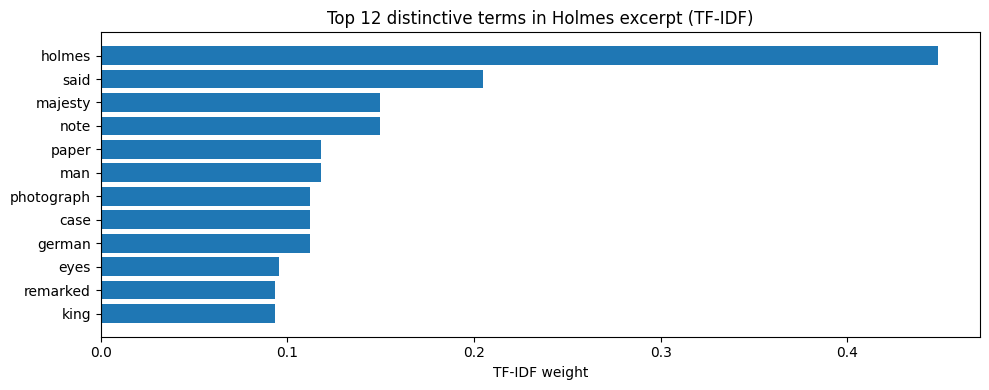

In [ ]:
top_n = CONFIG["visualization"]["top_tfidf"]
idx_holmes = labels.index("holmes")
top = top_tfidf(idx_holmes, n=top_n)
term_names, term_vals = zip(*top)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(range(len(term_names)), term_vals, align="center")
ax.set_yticks(range(len(term_names)))
ax.set_yticklabels(term_names)
ax.invert_yaxis()
ax.set_xlabel("TF-IDF weight")
ax.set_title(f"Top {top_n} distinctive terms in Holmes excerpt (TF-IDF)")
plt.tight_layout()
plt.show()

## N-grams

**Why it matters:** Single words ignore order; bigrams capture phrases like "my dear Watson" or "chest pain". We use `ngram_range=(1, 2)` so the vocabulary includes both unigrams and bigrams.

In [ ]:
cv_ngram = CountVectorizer(ngram_range=(1, 2))
X_ng = cv_ngram.fit_transform(docs)
bigrams = [t for t in cv_ngram.get_feature_names_out() if " " in t]
print("Sample bigrams:", bigrams[:30])

Sample bigrams: ['1858 contralto', '1888 was', '1894 by', '_am_ the', '_are_ the', '_carte blanche_', '_copyright 1894', '_curtseying_ as', '_have_ had', '_he_ can', '_her_ impossible', '_her_ mind', '_her_ the', '_incognito_ from', '_may_ fall', '_never_ come', '_not_ marked', '_one_ respectable', '_poison_ or', '_that_ but', '_that_ in', '_the_ woman', '_there_ what', '_through_ the', '_took watch', '_us_ to', '_very_ deeply', '_very_ good', '_very_ much', '_very_ remarkable']


## Visual: top bigrams

A bar chart of the most frequent bigrams shows that multi-word phrases carry meaning—useful for clinical phrases like "chest pain" or "no history of".

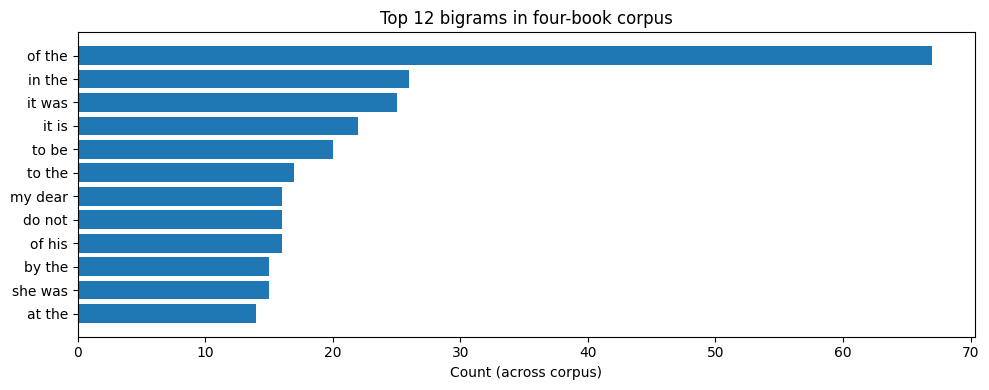

In [ ]:
bow_ng = CountVectorizer(ngram_range=(1, 2))
X_ng2 = bow_ng.fit_transform(docs)
names_ng = bow_ng.get_feature_names_out()
# Sum counts across all docs for bigrams only
bigram_counts = Counter()
for i in range(X_ng2.shape[0]):
    row = X_ng2[i].toarray().ravel()
    for j, name in enumerate(names_ng):
        if " " in name and row[j] > 0:
            bigram_counts[name] += row[j]
top_bigrams = bigram_counts.most_common(12)
b_names, b_vals = zip(*top_bigrams)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(range(len(b_names)), b_vals, align="center")
ax.set_yticks(range(len(b_names)))
ax.set_yticklabels(b_names)
ax.invert_yaxis()
ax.set_xlabel("Count (across corpus)")
ax.set_title("Top 12 bigrams in four-book corpus")
plt.tight_layout()
plt.show()

## Cosine similarity and heatmap

**Why it matters:** Once documents are vectors, we measure similarity with cosine similarity. Pairwise similarities form a matrix; a heatmap shows which documents are closest (e.g. two novels from the same period might cluster).

We compute the similarity matrix from the TF-IDF matrix and print it, then plot it as a heatmap so you can see blocks of similar vs dissimilar texts.

In [ ]:
sim = cosine_similarity(X)
print("Pairwise cosine similarity (TF-IDF):")
print(labels)
print(np.round(sim, 2))

Pairwise cosine similarity (TF-IDF):
['alice', 'holmes', 'pride', 'frankenstein']
[[1.   0.13 0.08 0.12]
 [0.13 1.   0.12 0.12]
 [0.08 0.12 1.   0.09]
 [0.12 0.12 0.09 1.  ]]


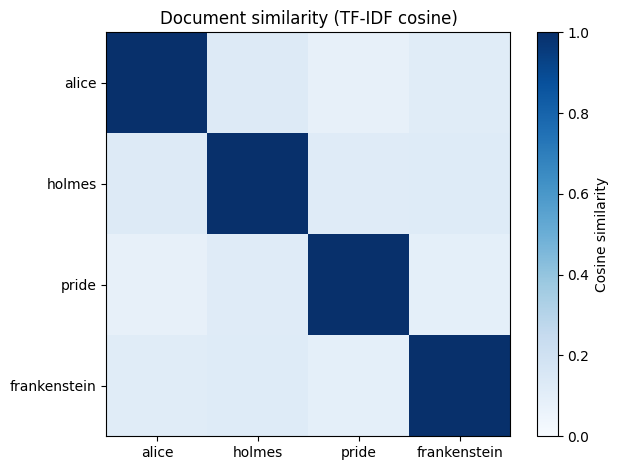

In [ ]:
fig, ax = plt.subplots()
im = ax.imshow(sim, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.colorbar(im, ax=ax, label="Cosine similarity")
ax.set_title("Document similarity (TF-IDF cosine)")
plt.tight_layout()
plt.show()

The diagonal is always 1.0 (each document is identical to itself). Off-diagonal values reveal relationships: Pride and Prejudice and Frankenstein show higher similarity (both 19th-century British novels with formal prose), while Alice stands apart (children's literature, whimsical vocabulary). Holmes falls somewhere in between. Low similarity scores (< 0.1) indicate texts with almost no shared distinctive vocabulary—expected from different genres and time periods.

## Query-based search

**Why it matters:** So far we've compared documents to each other. But often you want to search a corpus with a query—find which documents are most relevant to a question. This is the foundation of search engines and clinical decision support ("find notes similar to this presentation").

The key pattern: **fit** the vectorizer on your corpus, then **transform** the query separately. This ensures the query uses the same vocabulary as the corpus.

In [ ]:
# Fit TF-IDF on the corpus (creates vocabulary from documents)
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(docs)

# Transform a query using the fitted vocabulary
query = "detective mystery crime investigation"
query_vec = tfidf.transform([query])  # Note: transform, not fit_transform

# Compute similarity between query and each document
similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()

# Show results
for label, score in zip(labels, similarities):
    print(f"{label}: {score:.3f}")

alice: 0.000
holmes: 0.026
pride: 0.000
frankenstein: 0.000


The query gets vectorized using only terms that exist in the corpus vocabulary. If the query contains words not in the corpus, they're ignored. This is the same pattern you'd use to search clinical notes: fit on your note corpus, then transform incoming queries.

## Visual: query similarity scores

A bar chart makes it easy to see which documents best match the query—useful for presenting search results or explaining why a particular document was retrieved.

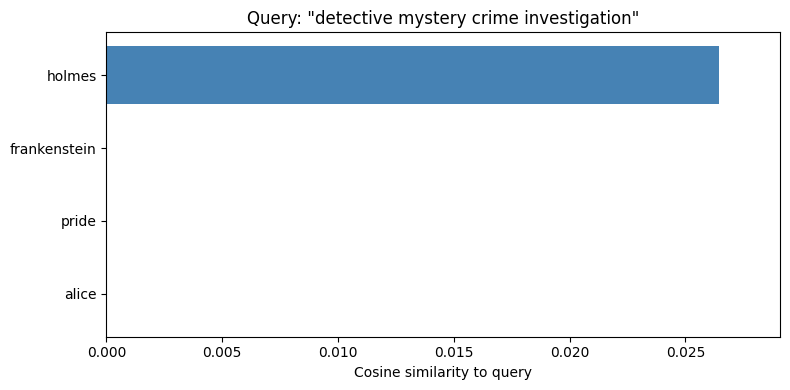

In [ ]:
# Visualize query-to-document similarity
query = "detective mystery crime investigation"
query_vec = tfidf.transform([query])
similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()

# Sort by similarity for clearer visualization
sorted_idx = np.argsort(similarities)[::-1]
sorted_labels = [labels[i] for i in sorted_idx]
sorted_scores = similarities[sorted_idx]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(range(len(sorted_labels)), sorted_scores, align="center", color="steelblue")
ax.set_yticks(range(len(sorted_labels)))
ax.set_yticklabels(sorted_labels)
ax.invert_yaxis()
ax.set_xlabel("Cosine similarity to query")
ax.set_title(f'Query: "{query}"')
ax.set_xlim(0, max(sorted_scores) * 1.1 if max(sorted_scores) > 0 else 1)
plt.tight_layout()
plt.show()

Try different queries: "rabbit wonderland" should match Alice; "marriage society manners" should match Pride and Prejudice; "monster creation science" should match Frankenstein. The pattern works for any domain—swap in clinical queries and clinical notes.

## NLTK pipeline

**Why it matters:** A pipeline bundles tokenization, normalization, lemmatization, POS, and NER into one function. NLTK requires you to call each step explicitly; that makes the flow clear and customizable.

We implement a function that returns tokens, nouns, and a flat list of entities (and optionally regex extractions). Running it on a short snippet shows the structure of the output.

In [ ]:
def nltk_pipeline(text: str) -> dict:
    tokens = nltk.word_tokenize(text.lower())
    stop_words = set(stopwords.words("english")) - {"no", "not"}
    tokens = [t for t in tokens if t not in string.punctuation and t not in stop_words]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    tagged = nltk.pos_tag(tokens)
    entities = nltk.ne_chunk(tagged)
    nouns = [w for w, tag in tagged if tag.startswith("NN")]
    ent_list = []
    for chunk in entities:
        if hasattr(chunk, "label"):
            ent_list.append((" ".join(c[0] for c in chunk), chunk.label()))
    return {"tokens": tokens, "nouns": nouns, "entities": ent_list}

result = nltk_pipeline(docs[0][:500])
print("Nouns (sample):", result["nouns"][:15])
print("Entities (sample):", result["entities"][:10])

Nouns (sample): ['alice', 'bank', 'nothing', 'book', 'sister', 'picture', 'conversation', '“', 'use', 'book', '”', 'picture', 'conversation', '”', 'day']
Entities (sample): []


## spaCy pipeline

**Why it matters:** spaCy runs tokenization, POS, lemmas, and NER in one call. You get a single `Doc` with all annotations, which is convenient for production and fast.

We implement a small wrapper that returns tokens, lemmas, nouns, and entities. Same interface idea as the NLTK pipeline so you can compare outputs.

In [ ]:
def spacy_pipeline(text: str) -> dict:
    doc = nlp(text)
    return {
        "tokens": [t.text for t in doc],
        "lemmas": [t.lemma_ for t in doc if not t.is_punct],
        "nouns": [t.lemma_ for t in doc if t.pos_ == "NOUN"],
        "entities": [(ent.text, ent.label_) for ent in doc.ents],
    }

result = spacy_pipeline(docs[0][:500])
print("Nouns (sample):", result["nouns"][:15])
print("Entities (sample):", result["entities"][:10])

Nouns (sample): ['sister', 'bank', 'book', 'sister', 'picture', 'conversation', 'use', 'book', 'picture', 'conversation', 'mind', 'day', 'pleasure', 'daisy', 'chain']
Entities (sample): [('Alice', 'PERSON'), ('Alice', 'PERSON')]


## Compare: when to use which?

| Aspect | NLTK Pipeline | spaCy Pipeline |
| ------ | ------------- | -------------- |
| Assembly | Manual, step-by-step | Automatic, one call |
| Customization | Full control at each step | Configure via pipeline components |
| NER quality | Basic | Better out-of-box |
| Speed | Slower | Faster |

Use NLTK when learning or when you need fine-grained control; use spaCy when building applications or when you need speed and better NER.

## Clinical Text

Apply the same vectorization and similarity techniques to clinical documents.

**TF-IDF for clinical document classification:**

In [ ]:
# What makes cardiology notes different from neurology notes?
clinical_docs = [
    "Patient with chest pain, elevated troponins, ST elevation. Started on heparin drip. Cardiology consulted for cath.",
    "Patient with chest discomfort, negative troponins, normal EKG. Stress test scheduled. Low risk for ACS.",
    "Patient presents with acute onset left-sided weakness, facial droop. CT head negative for hemorrhage. TPA administered.",
    "Patient with chronic headaches, normal neurological exam. MRI brain unremarkable. Migraine prophylaxis discussed.",
]
clinical_labels = ["cardiology_acute", "cardiology_low_risk", "neurology_stroke", "neurology_outpatient"]

tfidf_clinical = TfidfVectorizer(stop_words="english")
X_clinical = tfidf_clinical.fit_transform(clinical_docs)

# What terms distinguish each note type?
clinical_terms = tfidf_clinical.get_feature_names_out()
for i, label in enumerate(clinical_labels):
    row = X_clinical[i].toarray().ravel()
    top_idx = np.argsort(row)[::-1][:5]
    top_terms = [(clinical_terms[j], round(row[j], 2)) for j in top_idx if row[j] > 0]
    print(f"{label}: {top_terms}")

cardiology_acute: [('heparin', 0.29), ('cardiology', 0.29), ('elevation', 0.29), ('elevated', 0.29), ('drip', 0.29)]
cardiology_low_risk: [('acs', 0.3), ('ekg', 0.3), ('test', 0.3), ('stress', 0.3), ('low', 0.3)]
neurology_stroke: [('weakness', 0.27), ('sided', 0.27), ('head', 0.27), ('hemorrhage', 0.27), ('left', 0.27)]
neurology_outpatient: [('exam', 0.3), ('prophylaxis', 0.3), ('headaches', 0.3), ('unremarkable', 0.3), ('brain', 0.3)]


TF-IDF surfaces domain-specific vocabulary: "troponins" and "cath" for cardiology, "weakness" and "TPA" for stroke. This is the foundation for automated note classification, routing, and quality monitoring.

**Document similarity for clinical applications:**

In [ ]:
# Pairwise similarity between clinical notes
sim_clinical = cosine_similarity(X_clinical)
print("Clinical note similarity matrix:")
print(np.round(sim_clinical, 2))

Clinical note similarity matrix:
[[1.   0.14 0.02 0.02]
 [0.14 1.   0.07 0.08]
 [0.02 0.07 1.   0.02]
 [0.02 0.08 0.02 1.  ]]


Clinical similarity has practical uses:

| Application | How Similarity Helps |
| ----------- | -------------------- |
| **Case matching** | Find similar prior cases for clinical decision support |
| **Duplicate detection** | Flag copy-pasted notes or documentation errors |
| **Cohort building** | Group patients with similar presentations |
| **Template detection** | Identify over-reliance on templated text |

**N-grams capture clinical phrases:**

In [ ]:
# Bigrams matter even more in clinical text
cv_clinical = CountVectorizer(ngram_range=(2, 2), stop_words="english")
X_bigrams = cv_clinical.fit_transform(clinical_docs)
bigram_names = cv_clinical.get_feature_names_out()

# Sum across all docs
totals = X_bigrams.toarray().sum(axis=0)
top_bigram_idx = np.argsort(totals)[::-1][:10]
print("Top clinical bigrams:", [bigram_names[i] for i in top_bigram_idx])

Top clinical bigrams: ['patient chest', 'weakness facial', 'migraine prophylaxis', 'left sided', 'heparin drip', 'hemorrhage tpa', 'headaches normal', 'head negative', 'facial droop', 'exam mri']


Clinical bigrams like "chest pain", "negative troponins", "facial droop" carry more meaning than individual words. The phrase "left sided weakness" is a specific neurological finding; the words "left", "sided", and "weakness" separately are ambiguous.

## Specialized spaCy Models for Clinical and Biomedical Text

General spaCy models (`en_core_web_sm/md/lg`) are trained on web text. For clinical and scientific text, specialized models perform better:

| Model | Domain | Key Features |
| ----- | ------ | ------------ |
| **scispaCy** | Biomedical literature | Trained on PubMed/PMC; recognizes genes, chemicals, diseases |
| `en_core_sci_sm/md/lg` | Scientific | Small/medium/large variants; `_md` and `_lg` include word vectors |
| `en_ner_bc5cdr_md` | Chemicals & diseases | Specialized NER for drugs and conditions |
| **MedSpaCy** | Clinical notes | Negation detection, section tagging, target matching |

See [scispaCy docs](https://allenai.github.io/scispacy/) for current model URLs.

In [ ]:
# Installing and using scispaCy (not run here—requires separate install)
#
# pip install scispacy
# pip install <model_url_from_scispacy_docs>  # e.g., en_core_sci_md
#
# import spacy
# nlp_sci = spacy.load("en_core_sci_md")
# doc = nlp_sci("Metformin is used to treat type 2 diabetes mellitus.")
# for ent in doc.ents:
#     print(f"{ent.text}: {ent.label_}")
# # Metformin: CHEMICAL
# # type 2 diabetes mellitus: DISEASE

**MedSpaCy for negation and clinical context:**

In [ ]:
# MedSpaCy adds clinical-specific pipeline components (not run here)
#
# pip install medspacy
#
# import medspacy
# nlp_med = medspacy.load()
# doc = nlp_med("Patient denies chest pain. No fever. History of hypertension.")
#
# # MedSpaCy marks negated entities
# for ent in doc.ents:
#     print(f"{ent.text}: negated={ent._.is_negated}")
# # chest pain: negated=True
# # fever: negated=True
# # hypertension: negated=False (it's historical, not negated)

**Choosing your clinical NLP stack:**

| Task | Recommended Approach |
| ---- | -------------------- |
| Learning / prototyping | Standard spaCy + custom regex |
| Biomedical literature (PubMed) | scispaCy (`en_core_sci_md`) |
| Clinical notes with negation | MedSpaCy |
| Production clinical NLP | MedSpaCy or commercial tools (AWS Comprehend Medical, Google Healthcare NLP) |
| Concept normalization (to ICD/SNOMED) | QuickUMLS, MetaMap, or cTAKES |

The techniques you learned on Victorian novels—tokenization, TF-IDF, similarity, pipelines—are the same ones powering clinical NLP systems. The difference is the domain-specific models and the additional layers (negation, uncertainty, temporality) that clinical text requires.